In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = '#1 final feature selected dataset 2 for boiler efficiency.xlsx'
df_raw_1 = pd.read_excel(file_path)

In [3]:
df_raw_1

,Pressure (Kpa),Opacity (%),Temp. (°C),Nox (mg/nm3),Dust (mg/nm3),Boiler Eff (%)
0,-0.268340,49.690183,103.555908,215.343399,0.269452,77.915748
1,-0.254642,49.691542,99.353094,186.102138,0.270812,76.294873
2,-0.248897,49.697809,95.308560,188.988139,0.272701,77.886219
3,-0.225933,49.702891,87.355418,194.010835,0.274674,78.367624
4,-0.235743,49.688853,89.364968,132.718747,0.283205,77.856369
...,...,...,...,...,...,...
544,-0.287959,49.763117,108.685235,122.735621,7.591082,89.855113
545,-0.221320,49.763391,106.464384,141.549158,7.572601,88.052730
546,-0.106860,49.768304,102.674362,150.265522,7.570885,85.018900
547,-0.113589,49.766662,108.668248,135.204496,7.570648,83.295960


In [4]:
# Pisahkan fitur dari target (Analisis VIF hanya dilakukan pada fitur input)
target_cols = ['Boiler Eff (%)']
X_raw = df_raw_1.drop(columns=target_cols)

In [5]:
X_raw

,Pressure (Kpa),Opacity (%),Temp. (°C),Nox (mg/nm3),Dust (mg/nm3)
0,-0.268340,49.690183,103.555908,215.343399,0.269452
1,-0.254642,49.691542,99.353094,186.102138,0.270812
2,-0.248897,49.697809,95.308560,188.988139,0.272701
3,-0.225933,49.702891,87.355418,194.010835,0.274674
4,-0.235743,49.688853,89.364968,132.718747,0.283205
...,...,...,...,...,...
544,-0.287959,49.763117,108.685235,122.735621,7.591082
545,-0.221320,49.763391,106.464384,141.549158,7.572601
546,-0.106860,49.768304,102.674362,150.265522,7.570885
547,-0.113589,49.766662,108.668248,135.204496,7.570648


In [6]:
# # 2. Preprocessing Dasar
# # Menghilangkan kolom dengan variansi nol (konstanta) yang bisa merusak VIF
# X_raw = X_raw.loc[:, X_raw.var() > 0]
# X_raw = X_raw.fillna(X_raw.median())

In [7]:
# 2. Normalisasi (Z-Score Scaling)
# Ini wajib karena VIF didasarkan pada regresi; perbedaan skala (misal Pressure vs Flow) 
# akan mengacaukan perhitungan jika tidak dinormalisasi.
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_values, columns=X_raw.columns)

In [8]:
# 3. Perhitungan VIF untuk SEMUA fitur
def calculate_all_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    
    vif_list = []
    for i in range(len(data_frame.columns)):
        try:
            vif = variance_inflation_factor(data_frame.values, i)
            vif_list.append(vif)
        except Exception as e:
            # Jika ada varians nol, VIF akan menghasilkan nilai tak terhingga (inf)
            vif_list.append(np.inf)
            
    vif_data["VIF"] = vif_list
    return vif_data.sort_values(by="VIF", ascending=False)

In [9]:
# 1. Atur Pandas agar menampilkan 2 angka di belakang koma (tanpa eksponen)
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

In [10]:
# Eksekusi perhitungan
vif_results = calculate_all_vif(X_scaled)

In [11]:
vif_results

,Feature,VIF
0,Pressure (Kpa),1.95
1,Opacity (%),1.50
2,Temp. (°C),1.48
3,Nox (mg/nm3),1.05
4,Dust (mg/nm3),1.04


Nilai VIF <10 untuk semua fitur terpilih menggunakan feature engineering MrMiMaxG-CVM

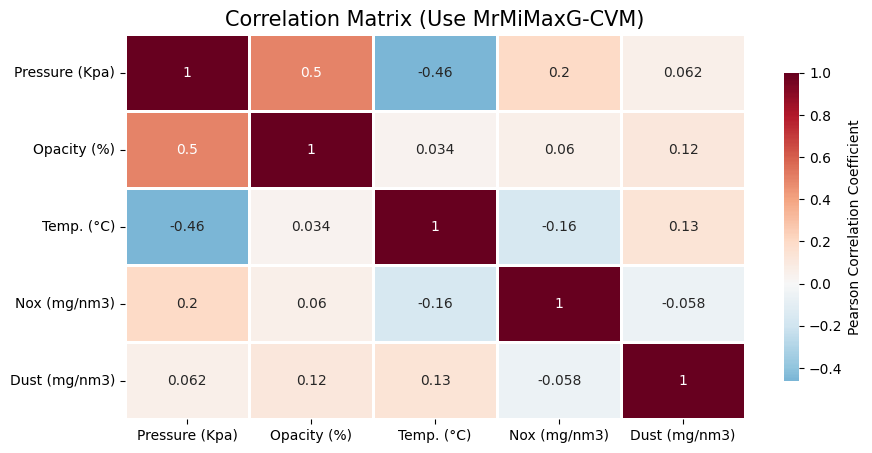

In [12]:
# A. Heatmap Korelasi (Matriks Kompleks)
plt.figure(figsize=(10, 5))
mask = np.tril(np.ones_like(X_scaled.corr(), dtype=bool))
sns.heatmap(X_scaled.corr(), 
            mask=None,          # Menampilkan format rectangle penuh
            annot=True,        # False karena 33 fitur terlalu padat untuk angka
            cmap='RdBu_r',      # Red-Blue (Merah = Positif, Biru = Negatif)
            center=0,           # Putih adalah korelasi 0
            linewidths=1,     # Memberikan garis tipis antar kotak (rectangle)
            linecolor='white',
            square=False,       # Memaksa format mengikuti aspek rasio figsize
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient"})
plt.title('Correlation Matrix (Use MrMiMaxG-CVM)', fontsize=15)
plt.show()

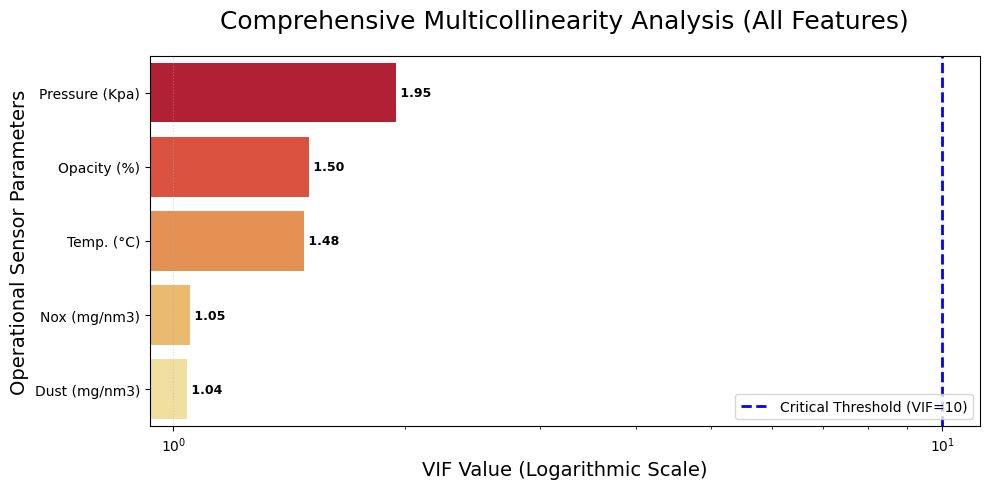

In [13]:
# 2. Mengatasi nilai 'inf' agar bisa tampil di grafik
max_real_vif = vif_results[vif_results['VIF'] != np.inf]['VIF'].max()
vif_results['VIF_Display'] = vif_results['VIF'].replace(np.inf, max_real_vif * 1.5)

# 3. Setup Figure
plt.figure(figsize=(10, 5))

# 4. Plot Bar Chart (PERBAIKAN DI SINI)
# Assign y ke hue dan tambahkan legend=False untuk menghilangkan warning
ax = sns.barplot(
    x='VIF_Display', 
    y='Feature', 
    data=vif_results, 
    palette='YlOrRd_r', 
    hue='Feature',    # Tambahkan ini
    legend=False      # Tambahkan ini
)

# 5. MENGGUNAKAN SKALA LOGARITMIK
plt.xscale('log')

# 6. Menambahkan Garis Threshold VIF=10
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Critical Threshold (VIF=10)')

# 7. Menambahkan Label Angka di ujung bar
# Menggunakan zip untuk memastikan sinkronisasi data dengan bar
for i, (p, feature_name) in enumerate(zip(ax.patches, vif_results['Feature'])):
    width = p.get_width()
    # Mengambil nilai asli dari dataframe berdasarkan urutan index saat ini
    original_vif = vif_results.iloc[i]['VIF']
    label_text = 'inf' if original_vif == np.inf else f"{original_vif:.2f}"
    
    ax.text(width, p.get_y() + p.get_height()/2, f' {label_text}', 
            va='center', fontsize=9, fontweight='bold')

# 8. Judul dan Label
plt.title('Comprehensive Multicollinearity Analysis (All Features)', fontsize=18, pad=20)
plt.xlabel('VIF Value (Logarithmic Scale)', fontsize=14)
plt.ylabel('Operational Sensor Parameters', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

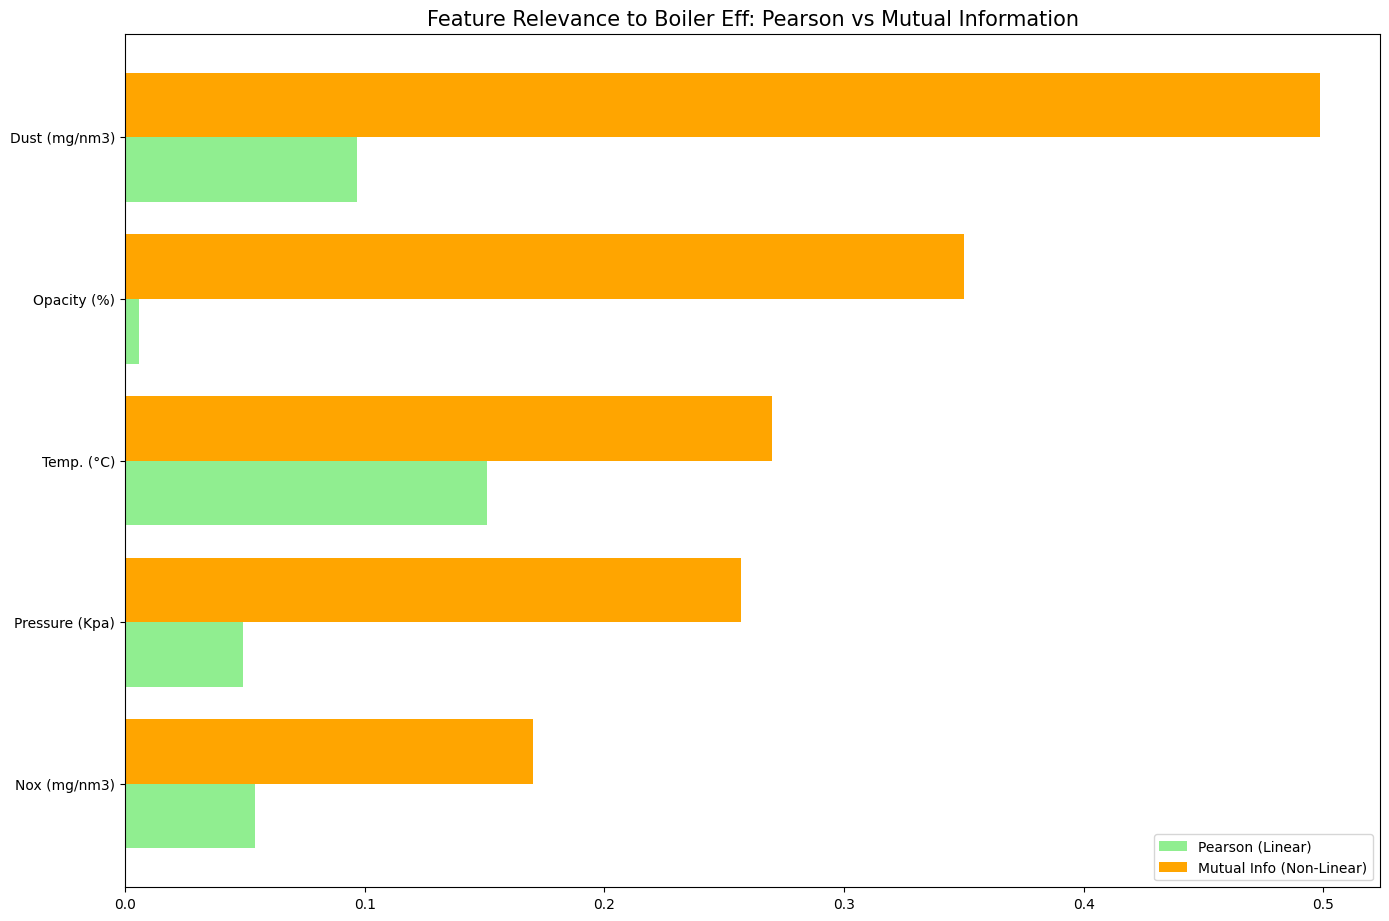

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Load Data
# df_raw_1 sudah didefinisikan sebelumnya
target_cols = ['Boiler Eff (%)']
X = df_raw_1.drop(columns=target_cols)
y_eff = df_raw_1['Boiler Eff (%)']

# 2. Hitung Korelasi Pearson (Linear) terhadap Target
pearson_eff = X.corrwith(y_eff).abs()

# 3. Hitung Mutual Information (Non-Linear) terhadap Target
# Kita perlu mengisi NaN jika ada agar MI bisa berjalan
X_fill = X.fillna(X.median())
mi_eff = mutual_info_regression(X_fill, y_eff, random_state=42)

# 4. Gabungkan dalam DataFrame untuk Visualisasi
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Pearson_Eff': pearson_eff.values,
    'MI_Eff': mi_eff
}).sort_values(by='MI_Eff', ascending=False)

# 5. Visualisasi Perbandingan Pearson vs MI (Justifikasi MrMiMaxG)
plt.figure(figsize=(14, 18))

# Subplot 2: Terhadap Boiler Efficiency
plt.subplot(2, 1, 2)
df_plot_eff = importance_df.sort_values('MI_Eff', ascending=True)
y_pos = np.arange(len(df_plot_eff))
plt.barh(y_pos - 0.2, df_plot_eff['Pearson_Eff'], 0.4, label='Pearson (Linear)', color='lightgreen')
plt.barh(y_pos + 0.2, df_plot_eff['MI_Eff'], 0.4, label='Mutual Info (Non-Linear)', color='orange')
plt.yticks(y_pos, df_plot_eff['Feature'])
plt.title('Feature Relevance to Boiler Eff: Pearson vs Mutual Information', fontsize=15)
plt.legend()

plt.tight_layout()
plt.show()